# Ejercicio 4: Modelo Probabilístico

## Objetivo de la práctica
- Comprender los componentes del modelo vectorial mediante cálculos manuales y observación directa.
- Aplicar el modelo de espacio vectorial con TF-IDF para recuperar documentos relevantes.
- Comparar la recuperación con BM25 frente a TF-IDF.
- Analizar visualmente las diferencias entre los modelos.
- Evaluar si los rankings generados son consistentes con lo que considerarías documentos relevantes.

Nombre: Pérez Pineda Andrés Alejandro

## Parte 0: Carga del Corpus

Utilizaremos el corpus `Gutenberg 1000`

In [14]:
import os
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Ruta inteligente (Maneja la ejecución en Docker, Windows o Mac)
directorio_base = os.getcwd()
if os.path.basename(directorio_base) != 'work' and os.path.exists('work'):
    os.chdir('work')
    directorio_base = os.getcwd()

carpeta_gutenberg = os.path.join(directorio_base, "data", "gutenberg_1000")

print("--- PASO 0: Verificación, Descarga y Carga del Corpus Gutenberg ---")

# Verificación y descarga de los libros por si no se tienen en la misma carpeta donde se encuentra este código
if not os.path.exists(carpeta_gutenberg):
    os.makedirs(carpeta_gutenberg)

archivos_existentes = [f for f in os.listdir(carpeta_gutenberg) if f.endswith('.txt')]
libros_descargados = len(archivos_existentes)
num_libros_objetivo = 1000

if libros_descargados < num_libros_objetivo:
    print(f"Faltan libros (tienes {libros_descargados} de {num_libros_objetivo}). Iniciando descarga...")
    print("Esto tomará varios minutos. Por favor, ten paciencia.")
    
    libros_exitosos = libros_descargados
    id_libro = 1 # El ID inicial de Project Gutenberg
    
    while libros_exitosos < num_libros_objetivo:
        ruta_guardado = os.path.join(carpeta_gutenberg, f"libro_{id_libro}.txt")
        
        # Si este libro ya existe localmente, lo saltamos
        if os.path.exists(ruta_guardado):
            id_libro += 1
            continue
            
        url = f"https://www.gutenberg.org/cache/epub/{id_libro}/pg{id_libro}.txt"
        try:
            respuesta = requests.get(url, timeout=5)
            # Solo guardamos si la petición fue exitosa y es texto plano
            if respuesta.status_code == 200 and "text/plain" in respuesta.headers.get("Content-Type", ""):
                with open(ruta_guardado, 'w', encoding='utf-8') as f:
                    f.write(respuesta.text)
                libros_exitosos += 1
                if libros_exitosos % 50 == 0: # Imprime un aviso cada 50 libros
                    print(f"  -> Descargados {libros_exitosos}/{num_libros_objetivo} libros...")
            time.sleep(0.5) # Pausa de medio segundo para no saturar el servidor de Gutenberg
        except requests.RequestException:
            pass # Ignoramos errores de red y probamos con el siguiente ID
            
        id_libro += 1
    print("Descarga completada con éxito.\n")
else:
    print(f"Ya existen los {libros_descargados} libros. Se omite la descarga.\n")


# Carga los libros a la memoria
corpus_gutenberg = []
nombres_documentos = []

archivos_finales = [f for f in os.listdir(carpeta_gutenberg) if f.endswith('.txt')]

print("Cargando libros en memoria...")
for archivo in archivos_finales: 
    ruta_completa = os.path.join(carpeta_gutenberg, archivo)
    with open(ruta_completa, 'r', encoding='utf-8', errors='ignore') as f:
        texto = f.read()
        corpus_gutenberg.append(texto)
        nombres_documentos.append(archivo)
        
print(f"¡Listo! Cargados {len(corpus_gutenberg)} documentos del corpus Gutenberg local.")

--- PASO 0: Verificación, Descarga y Carga del Corpus Gutenberg ---
Ya existen los 1000 libros. Se omite la descarga.

Cargando libros en memoria...
¡Listo! Cargados 1000 documentos del corpus Gutenberg local.


## Parte 1: Cálculo de TF, DF, IDF y TF-IDF

### Actividad 
1. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)
2. Calcula TF-IDF utilizando sklearn.
3. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos.

In [16]:
print("PARTE 1: TF-IDF con Scikit-Learn")

# 1 y 2. Construye la matriz TF-IDF (Scikit-Learn maneja TF y DF por debajo)
vectorizer_tfidf = TfidfVectorizer(stop_words='english', max_features=10000)
matriz_tfidf = vectorizer_tfidf.fit_transform(corpus_gutenberg)
vocabulario = vectorizer_tfidf.get_feature_names_out()

print(f"Dimensiones de la matriz TF-IDF: {matriz_tfidf.shape}")

# 3. Permite visualizar un fragmento en un DataFrame de Pandas
num_libros = 25
num_palabras = 50

df_tfidf = pd.DataFrame(
    matriz_tfidf[:num_libros, :num_palabras].toarray(), 
    columns=vocabulario[:num_palabras], 
    index=nombres_documentos[:num_libros]
)
print(f"\nMuestra de la matriz TF-IDF ({num_libros} documentos, {num_palabras} términos):")
display(df_tfidf)

PARTE 1: TF-IDF con Scikit-Learn
Dimensiones de la matriz TF-IDF: (1000, 10000)

Muestra de la matriz TF-IDF (25 documentos, 50 términos):


,000,0000,00000,000000,001,002,003,004,005,006,...,034,04,047,05,06,07,07042,09,10,100
libro_1.txt,0.010482,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.005325,0.0,0.009597,0.000000
libro_10.txt,0.000028,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000028,0.0,0.107378,0.000402
libro_100.txt,0.000039,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000040,0.0,0.000143,0.000377
libro_1000.txt,0.000050,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000051,0.0,0.000000,0.000000
libro_1001.txt,0.000954,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000969,0.0,0.000000,0.000000
libro_1002.txt,0.001033,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.001049,0.0,0.000000,0.000000
libro_1003.txt,0.000996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.001012,0.0,0.000000,0.000000
libro_1004.txt,0.000349,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000355,0.0,0.000000,0.000000
libro_1005.txt,0.000969,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000984,0.0,0.000000,0.000000
libro_1006.txt,0.000980,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000996,0.0,0.000000,0.000000


## Parte 2: Ranking de documentos usando TF-IDF

### Actividad 

1. Dada una consulta, construye el vector de consulta
2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
3. Genera un ranking de los documentos ordenados por relevancia.
4. Muestra los resultados en una tabla.

In [17]:
print("PARTE 2: Ranking con TF-IDF")
consulta = "science fiction adventure"

# 1. Vector de consulta
vector_consulta = vectorizer_tfidf.transform([consulta])

# 2. Similitud coseno
similitudes_tfidf = cosine_similarity(vector_consulta, matriz_tfidf).flatten()

# 3. Generar ranking
indices_top_tfidf = similitudes_tfidf.argsort()[-20:][::-1]

# 4. Muestra la tabla generada, con el ranking del paso anterior
print(f"\nResultados TF-IDF para: '{consulta}'")
print("-" * 50)
for i in indices_top_tfidf:
    print(f"Documento: {nombres_documentos[i]:<15} | Similitud: {similitudes_tfidf[i]:.4f}")

PARTE 2: Ranking con TF-IDF

Resultados TF-IDF para: 'science fiction adventure'
--------------------------------------------------
Documento: libro_726.txt   | Similitud: 0.0970
Documento: libro_235.txt   | Similitud: 0.0929
Documento: libro_505.txt   | Similitud: 0.0924
Documento: libro_1016.txt  | Similitud: 0.0918
Documento: libro_724.txt   | Similitud: 0.0787
Documento: libro_728.txt   | Similitud: 0.0774
Documento: libro_470.txt   | Similitud: 0.0588
Documento: libro_852.txt   | Similitud: 0.0539
Documento: libro_444.txt   | Similitud: 0.0518
Documento: libro_695.txt   | Similitud: 0.0506
Documento: libro_884.txt   | Similitud: 0.0448
Documento: libro_887.txt   | Similitud: 0.0410
Documento: libro_626.txt   | Similitud: 0.0396
Documento: libro_381.txt   | Similitud: 0.0395
Documento: libro_979.txt   | Similitud: 0.0385
Documento: libro_101.txt   | Similitud: 0.0376
Documento: libro_1017.txt  | Similitud: 0.0375
Documento: libro_743.txt   | Similitud: 0.0371
Documento: libro_774.t

## Parte 3: Ranking con BM25

### Actividad 

1. Implementa un sistema de recuperación usando el modelo BM25.
2. Usa la misma consulta del ejercicio anterior.
3. Calcula el score BM25 para cada documento y genera un ranking.
4. Compara manualmente con el ranking de TF-IDF.

### Algoritmo BM25:

1. Tokenización
2. Calcular longitudes de documentos y promedio de longitud
3. Calcular TF (frecuencia de término por documento)
4. Calcular DF (document frequency) e IDF de BM25
5. Definir los parámetros de BM25 (k1, b)
6. Implementar la función de score BM25 para un documento
7. Función para calcular la probabilidad para todos los documentos de la colección a partir de una query
8. Recuperar los documentos mejor puntuados (ranking)

In [21]:
print("PARTE 3: Modelo Probabilístico BM25")

# 1. Tokenización (Utiliza CountVectorizer para extraer las frecuencias puras TF)
vectorizer_tf = CountVectorizer(stop_words='english', max_features=10000)
matriz_tf = vectorizer_tf.fit_transform(corpus_gutenberg).toarray()
vocab_bm25 = vectorizer_tf.get_feature_names_out()
vocab_dict = {term: idx for idx, term in enumerate(vocab_bm25)}

# 2. Calcula las longitudes de documentos (|d|) y promedio (avgdl)
longitudes_doc = matriz_tf.sum(axis=1) 
avgdl = longitudes_doc.mean()
N = len(corpus_gutenberg)

# 3 y 4. Calcula el DF e IDF (Implementando la fórmula teórica del documento)
df = (matriz_tf > 0).sum(axis=0)

# IDF con corrección de 0.5 (Aprox. RSJ sin relevancia)
idf = np.log((N - df + 0.5) / (df + 0.5))
# Piso en 0 para evitar valores negativos en términos muy frecuentes
idf[idf < 0] = 0 

# 5. Define los parámetros BM25 (Se usan los rangos típicos recomendados por el Prof. Carrera)
k1 = 1.5   # Controla saturación tf (entre 1.2 y 2.0)
b = 0.75   # Controla normalización por longitud

# 6 y 7. Función de score general BM25
def calcular_bm25(query, vocab_dict, matriz_tf, idf, longitudes_doc, avgdl, k1, b):
    scores = np.zeros(N)
    terminos_query = query.lower().split()
    
    for termino in terminos_query:
        if termino in vocab_dict:
            idx_t = vocab_dict[termino]
            idf_t = idf[idx_t]
            tf_td = matriz_tf[:, idx_t]
            
            # Fórmula estándar BM25 del documento
            numerador = (k1 + 1) * tf_td
            denominador = k1 * ((1 - b) + b * (longitudes_doc / avgdl)) + tf_td
            
            score_termino = idf_t * (numerador / denominador)
            scores += score_termino
    return scores

# 8. Genera el ranking BM25
scores_bm25 = calcular_bm25(consulta, vocab_dict, matriz_tf, idf, longitudes_doc, avgdl, k1, b)
indices_top_bm25 = scores_bm25.argsort()[-20:][::-1]

print(f"\nResultados BM25 para: '{consulta}'")
print("-" * 50)
for i in indices_top_bm25:
    print(f"Documento: {nombres_documentos[i]:<15} | Score BM25: {scores_bm25[i]:.8f}")

PARTE 3: Modelo Probabilístico BM25

Resultados BM25 para: 'science fiction adventure'
--------------------------------------------------
Documento: libro_1016.txt  | Score BM25: 1.90856492
Documento: libro_314.txt   | Score BM25: 1.90721484
Documento: libro_726.txt   | Score BM25: 1.88848236
Documento: libro_724.txt   | Score BM25: 1.88536611
Documento: libro_101.txt   | Score BM25: 1.86991631
Documento: libro_235.txt   | Score BM25: 1.85741653
Documento: libro_915.txt   | Score BM25: 1.85173248
Documento: libro_887.txt   | Score BM25: 1.85121343
Documento: libro_728.txt   | Score BM25: 1.84429543
Documento: libro_470.txt   | Score BM25: 1.84011641
Documento: libro_817.txt   | Score BM25: 1.78347805
Documento: libro_590.txt   | Score BM25: 1.77090694
Documento: libro_38.txt    | Score BM25: 1.76555252
Documento: libro_532.txt   | Score BM25: 1.76178754
Documento: libro_625.txt   | Score BM25: 1.75921787
Documento: libro_492.txt   | Score BM25: 1.75860145
Documento: libro_381.txt   | S

## Parte 4: Comparación visual entre TF-IDF y BM25

### Actividad 

1. Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.
2. Compara los rankings visualmente.
3. ¿Qué documentos obtienen scores más altos en un modelo que en otro?
4. ¿A qué se podría deber esta diferencia?

PARTE 4: Comparación Visual


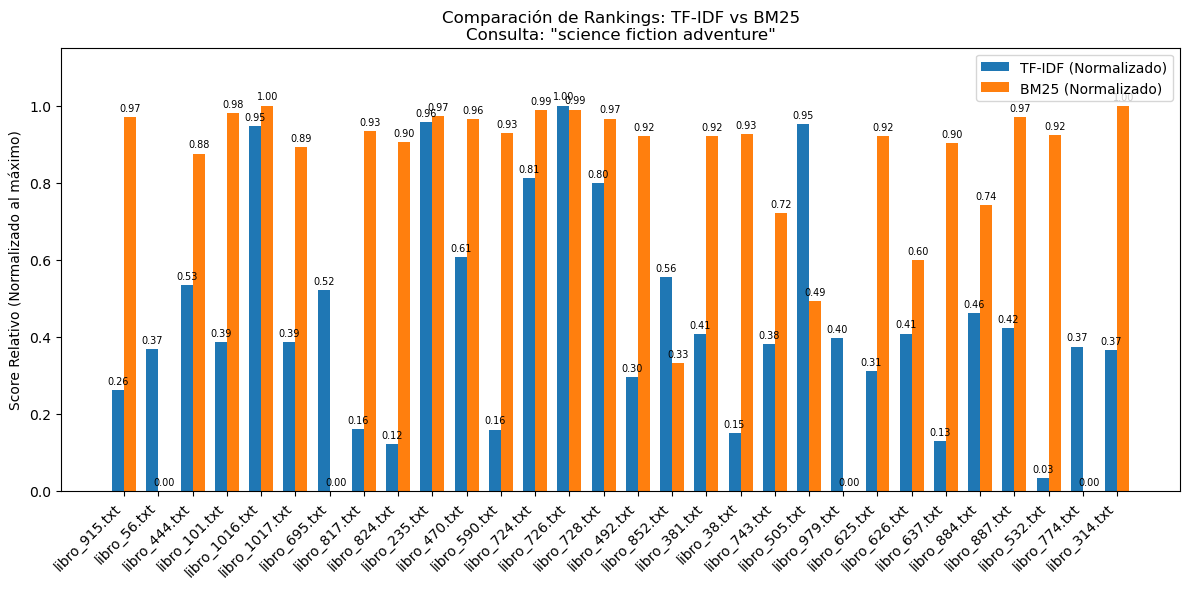

In [25]:
print("PARTE 4: Comparación Visual")

# Obtiene los documentos únicos que aparecen en el Top de cualquiera de los dos modelos
top_combinados = list(set(indices_top_tfidf) | set(indices_top_bm25))
nombres_top = [nombres_documentos[i] for i in top_combinados]
scores_t_top = [similitudes_tfidf[i] for i in top_combinados]
scores_b_top = [scores_bm25[i] for i in top_combinados]

# Normaliza los scores al rango 0-1 para poder graficarlos juntos sin que BM25 aplaste a TF-IDF
max_t = max(scores_t_top) if max(scores_t_top) > 0 else 1
max_b = max(scores_b_top) if max(scores_b_top) > 0 else 1
scores_t_norm = [s / max_t for s in scores_t_top]
scores_b_norm = [s / max_b for s in scores_b_top]

# Realiza la configuración del gráfico de barras agrupadas
x = np.arange(len(nombres_top))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6)) # Un poco más ancho para que quepan los números
rects1 = ax.bar(x - width/2, scores_t_norm, width, label='TF-IDF (Normalizado)')
rects2 = ax.bar(x + width/2, scores_b_norm, width, label='BM25 (Normalizado)')

# Muestra los valores en la barras del gráfico
ax.bar_label(rects1, padding=3, fmt='%.2f', fontsize=7)
ax.bar_label(rects2, padding=3, fmt='%.2f', fontsize=7)

ax.set_ylim(0, 1.15)

ax.set_ylabel('Score Relativo (Normalizado al máximo)')
ax.set_title(f'Comparación de Rankings: TF-IDF vs BM25\nConsulta: "{consulta}"')
ax.set_xticks(x)
ax.set_xticklabels(nombres_top, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()